# License

In [ ]:
# ------------------------------------------------------------------------------
#  QuantumThermal sample, written in Python
#
#  Multi-Scale Modeling Laboratory (SMaLL)
#  Website: https://small.polito.it/
#  GitHub repository: https://github.com/SMaLL-PoliTo/QuantumThermal
#
#  Copyright (C) 2025 Pietro Asinari, Matteo Maria Piredda,
#  Giulio Barletta, Paolo De Angelis
#  E-mail contact: pietro.asinari@polito.it
#
#  This code is licensed under the MIT License.
#  You may obtain a copy of the License at
#
#      https://opensource.org/licenses/MIT
#
#  Permission is hereby granted, free of charge, to any person obtaining a copy
#  of this software and associated documentation files (the "Software"), to deal
#  in the Software without restriction, including without limitation the rights
#  to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
#  copies of the Software, and to permit persons to whom the Software is
#  furnished to do so, subject to the following conditions:
#
#  The above copyright notice and this permission notice shall be included in
#  all copies or substantial portions of the Software.
#
#  THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
#  IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
#  FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
#  AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
#  LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
#  OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
#  SOFTWARE.
# ------------------------------------------------------------------------------

# Preparation

In [56]:
# Before running the code, it is necessary to create a conda environment as following:
# conda create -n thermal-science -y python=3.11 ipykernel
#
# Then activate the environment:
# conda activate thermal-science
# 
# Required packages will be installed with the first line of the code

%pip install numpy scipy matplotlib cvxpy pylatexenc
%pip install qiskit==1.4.2 qiskit-aer==0.17.2 qiskit-algorithms==0.3.1

from IPython.display import clear_output
clear_output()

In [57]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.linalg import inv, norm

n = 3 # number of qubits, num_qubits
N = pow(2,n) # number of mesh nodes

# T_old
T_old = np.ones(N)
for i in range(N):
    T_old[i] = 1 + (1/2)*np.sin(2*np.pi*(i+1)/N)
print(T_old)

# Linear system C*T_new = T_old
# T_new = inv(C)*T_old
r = 0.5 # = delta_t*alpha/(delta_x**2) = Fo, Fourier number 
d = np.ones(N)*(1+2*r)
od = np.ones(N-1)*(-r)
C = np.diag(d, 0) + np.diag(od, -1) + np.diag(od, 1)
C[0,N-1] = -r
C[N-1,0] = -r
print(C)

# T_new
T_new = inv(C) @ T_old
print(T_new)

[1.35355339 1.5        1.35355339 1.         0.64644661 0.5
 0.64644661 1.        ]
[[ 2.  -0.5  0.   0.   0.   0.   0.  -0.5]
 [-0.5  2.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  2.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.  -0.5  2.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.  -0.5  2.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.  -0.5  2.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  2.  -0.5]
 [-0.5  0.   0.   0.   0.   0.  -0.5  2. ]]
[1.27345908 1.38672954 1.27345908 1.         0.72654092 0.61327046
 0.72654092 1.        ]


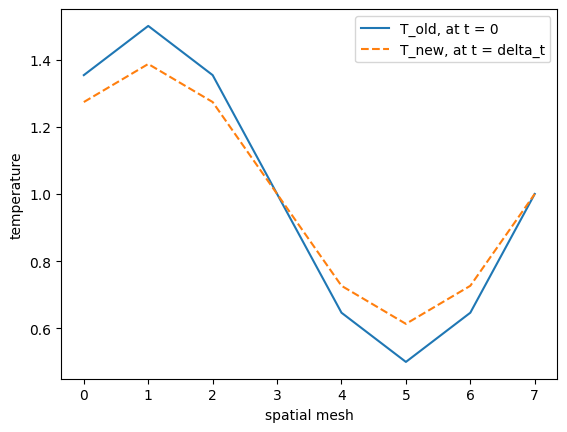

In [58]:
import matplotlib.pyplot as plt
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new, at t = delta_t', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

In [59]:
# T_old
TT_old = np.sum(T_old**2)
b0 = np.sqrt(TT_old)
b = T_old/b0

# T_new
TT_new = np.sum(T_new**2)
x0 = np.sqrt(TT_new)
x_th = T_new/x0 # (theoretical)

# Linear system (normalized)
f = np.sqrt(TT_new/TT_old) 
A = C*f # (normalized)

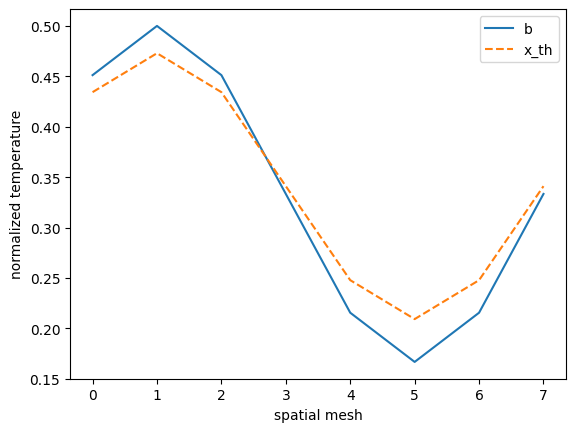

In [60]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

In [61]:
# Quantum observable for T_new, or better for |x> (normalized)
# O = A' ( I - |b><b| ) A
# <x|O|x> --> 0 (minimum) 
# 
# Ref: PHYSICAL REVIEW A 107, 052422 (2023)
# Depth analysis of variational quantum algorithms for the heat equation

O = np.identity(N)-np.outer(b,b)
O = np.matmul(O,A)
A_dag = np.transpose(A)
O = np.matmul(A_dag,O)

print(O)

[[ 4.07374369 -2.1653814   0.01346419 -0.15467348 -0.08397119 -0.05468534
   0.15486878 -2.06539325]
 [-2.1653814   4.01136652 -2.1653814   0.06406786 -0.0948826  -0.06179127
  -0.0948826   0.06406786]
 [ 0.01346419 -2.1653814   4.07374369 -2.06539325  0.15486878 -0.05468534
  -0.08397119 -0.15467348]
 [-0.15467348  0.06406786 -2.06539325  4.19296838 -1.96834848  0.20130989
  -0.05762871 -0.1061511 ]
 [-0.08397119 -0.0948826   0.15486878 -1.96834848  4.26783324 -1.93109459
   0.20755373 -0.05762871]
 [-0.05468534 -0.06179127 -0.05468534  0.20130989 -1.93109459  4.28585059
  -1.93109459  0.20130989]
 [ 0.15486878 -0.0948826  -0.08397119 -0.05762871  0.20755373 -1.93109459
   4.26783324 -1.96834848]
 [-2.06539325  0.06406786 -0.15467348 -0.1061511  -0.05762871  0.20130989
  -1.96834848  4.19296838]]


In [62]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator

observable = SparsePauliOp.from_operator(O)
print(observable)

SparsePauliOp(['III', 'IIX', 'IXI', 'IXX', 'IXZ', 'IYY', 'IZI', 'IZX', 'IZZ', 'XII', 'XIX', 'XXI', 'XXX', 'XXZ', 'XYY', 'XZI', 'XZX', 'XZZ', 'YIY', 'YXY', 'YYI', 'YYX', 'YYZ', 'YZY', 'ZII', 'ZIX', 'ZIZ', 'ZXI', 'ZXX', 'ZXZ', 'ZYY', 'ZZI', 'ZZX', 'ZZZ'],
              coeffs=[ 4.17078846+0.j, -2.03255443+0.j,  0.12159892+0.j, -1.07719455+0.j,
 -0.01108996+0.j, -0.97104345+0.j, -0.01108996+0.j, -0.01568357+0.j,
  0.01108996+0.j, -0.08397119+0.j, -0.09046753+0.j,  0.14377883+0.j,
 -1.04582742+0.j,  0.01108996+0.j,  0.97104345-0.j,  0.01108996+0.j,
  0.01568357+0.j, -0.01108996+0.j,  0.01421188-0.j,  0.01421188-0.j,
  0.03431051-0.j,  0.03431051-0.j, -0.03431051+0.j, -0.03431051+0.j,
 -0.0828329 +0.j, -0.0828329 +0.j, -0.01421188+0.j, -0.0828329 +0.j,
 -0.0828329 +0.j, -0.01421188+0.j, -0.03431051+0.j, -0.03431051+0.j,
 -0.03431051+0.j,  0.03431051+0.j])


In [63]:
from qiskit_algorithms import NumPyMinimumEigensolver

numpy_solver = NumPyMinimumEigensolver()
result = numpy_solver.compute_minimum_eigenvalue(operator = observable)
ref_value = result.eigenvalue.real
print(f"Reference value: {ref_value:.5f}")

Reference value: -0.00000


## Loss/cost function for VQE

In [64]:
def cost_func_vqe(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs

    return cost

## Ansatz

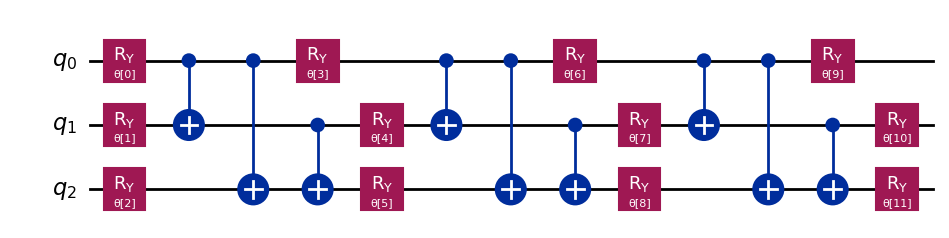

In [65]:
from qiskit.circuit.library import TwoLocal
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2

import numpy as np

num_qubits = n

# Best rational ansatz with minimum number of parameters
raw_ansatz = TwoLocal(num_qubits, rotation_blocks="ry", entanglement_blocks="cx", entanglement="full")

raw_ansatz.decompose().draw('mpl')

In [66]:
raw_ansatz.num_parameters

12

## Quantum simulator (qiskit)

In [67]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler
import numpy as np

estimator = Estimator()
sampler = Sampler()

# Initial (arbitrary) set of parameter
theta0 = np.ones(raw_ansatz.num_parameters)

## Quantum minimization

In [68]:
# SciPy minimizer routine
from scipy.optimize import minimize
import time

# Variational quantum eigensolver (VQE)
# See https://learning.quantum.ibm.com/tutorial/variational-quantum-eigensolver
start_time = time.time()

result = minimize(cost_func_vqe, theta0, args=(raw_ansatz.decompose(), observable, estimator), 
                  method="COBYLA", 
                  tol = 1e-3, # better tolerance is possible but it would require more iterations/time
                  options={'maxiter': 10000, 'disp': True})
print(result)

end_time = time.time()
execution_time = end_time - start_time
print(f"""Time (s): {execution_time}""")

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 366   Least value of F = 1.0740118417491493e-06
The corresponding X is:
[1.5524449  1.79309038 1.99277067 1.56728143 0.96251285 1.34331082
 2.44686357 0.51786919 0.36780372 1.9360288  0.74234826 0.49130594]

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 1.0740118417491493e-06
       x: [ 1.552e+00  1.793e+00  1.993e+00  1.567e+00  9.625e-01
            1.343e+00  2.447e+00  5.179e-01  3.678e-01  1.936e+00
            7.423e-01  4.913e-01]
    nfev: 366
   maxcv: 0.0
Time (s): 2.2564971446990967


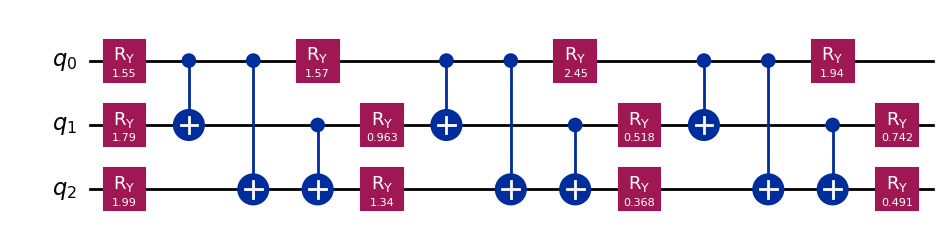

In [69]:
theta = result.x # Final optimized parameters
ansatz = raw_ansatz.assign_parameters(theta)
ansatz.decompose().draw('mpl')

## Simulted quantum results

In [70]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

ideal_distribution = Statevector.from_instruction(ansatz).probabilities_dict()

In [71]:
# Solution (quantum)
y = np.real(list(ideal_distribution.values())) # probabilities
x = np.sqrt(y) # amplitudes

## De-normalization by post-processing

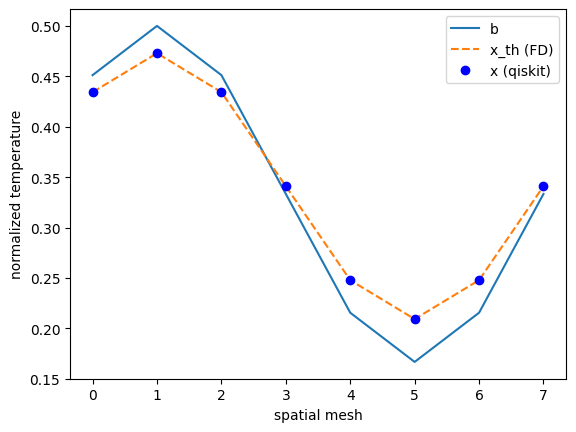

In [72]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th (FD)', linestyle='dashed')
plt.plot(x, 'bo', label='x (qiskit)')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

In [73]:
import statistics

x_mean = statistics.mean(x)
T_mean = statistics.mean(T_old)
scale = T_mean/x_mean
print(f"\nscale = {scale}")

T_new_q = x*scale


scale = 2.931954890064929


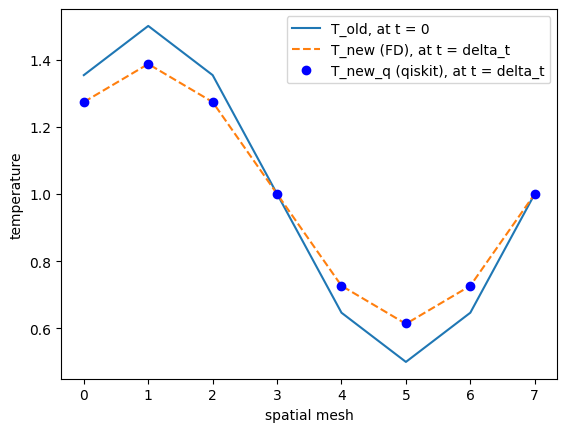

In [74]:
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

## Quantum simulator (qiskit shots with statistics)

In [75]:
# define ansatz and optimizer
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import SPSA

ansatz = TwoLocal(rotation_blocks="ry", entanglement_blocks="cx",
    entanglement = 'full', 
    skip_final_rotation_layer = True,
    reps = 4)
#ansatz = TwoLocal(rotation_blocks="ry", entanglement_blocks="cz", entanglement='linear', reps=4)

In [76]:
# define callback
# note: Re-run this cell to restart lists before training
counts = []
energy_values = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    energy_values.append(mean)

In [77]:
# define Aer Estimator for noiseless statevector simulation
from qiskit_algorithms.utils import algorithm_globals
from qiskit_aer.primitives import Estimator as AerEstimator
from qiskit.primitives import BackendEstimator
from qiskit_algorithms import VQE
from qiskit.quantum_info import Statevector
import time

noiseless_spsa = SPSA(maxiter = 100) # up to shots = 1000

repetitions = 5 # up to shots = 30
all_results = np.empty(repetitions, dtype = object)
all_counts = np.empty(repetitions, dtype = object)
all_energy_values = np.empty(repetitions, dtype = object)
for k in range(repetitions):
    seed = int(time.time())
    algorithm_globals.random_seed = seed

    noiseless_estimator = AerEstimator(
        run_options={"seed": seed, "shots": 1024*1, "noise_model": None}, # up to shots = 4000000
        transpile_options={"seed_transpiler": seed},
    )

    vqe = VQE(noiseless_estimator, ansatz, optimizer = noiseless_spsa, callback = store_intermediate_result)
    noiseless_result = vqe.compute_minimum_eigenvalue(operator = observable)

    noiseless_theta = noiseless_result.optimal_point # final optimized parameters
    noiseless_ansatz = ansatz.assign_parameters(noiseless_theta)
    noiseless_distribution = Statevector.from_instruction(noiseless_ansatz).probabilities_dict()
    all_results[k] = noiseless_distribution
    all_counts[k] = counts
    all_energy_values[k] = energy_values

    counts = []
    energy_values = []

    print(f"repetition: {k}")

repetition: 0
repetition: 1
repetition: 2
repetition: 3
repetition: 4


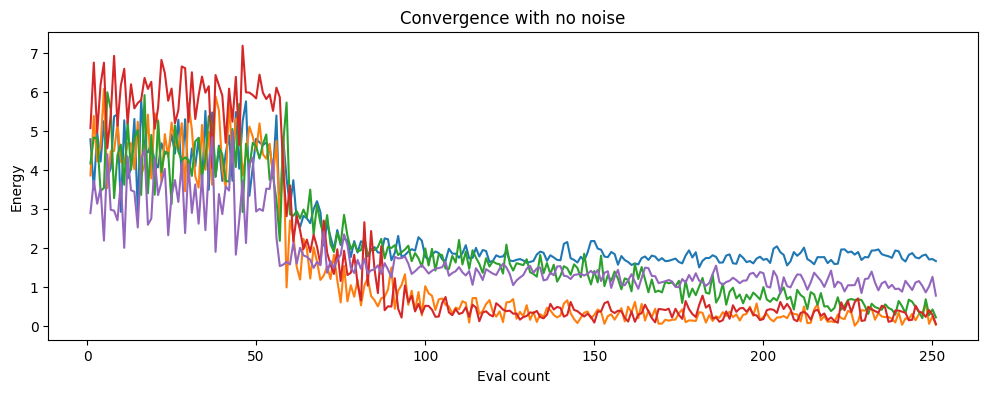

In [78]:
import pylab

pylab.rcParams["figure.figsize"] = (12, 4) # default (6.4, 4.8)

all_values = []
for k in range(repetitions):
    counts = all_counts[k]
    energy_values = all_energy_values[k]

    pylab.plot(counts, energy_values)

pylab.xlabel("Eval count")
pylab.ylabel("Energy")
pylab.title("Convergence with no noise")
plt.show()

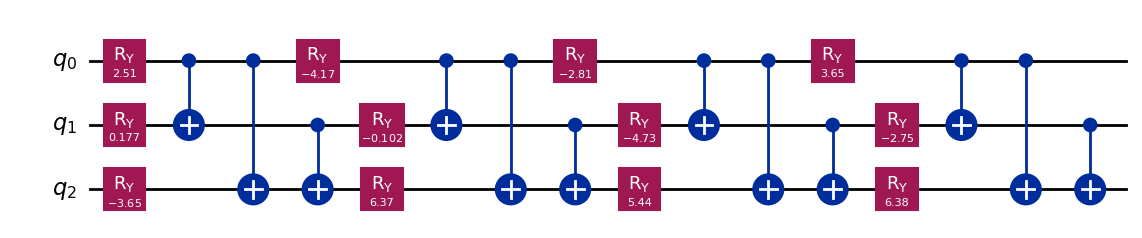

In [79]:
noiseless_ansatz.decompose().draw('mpl')

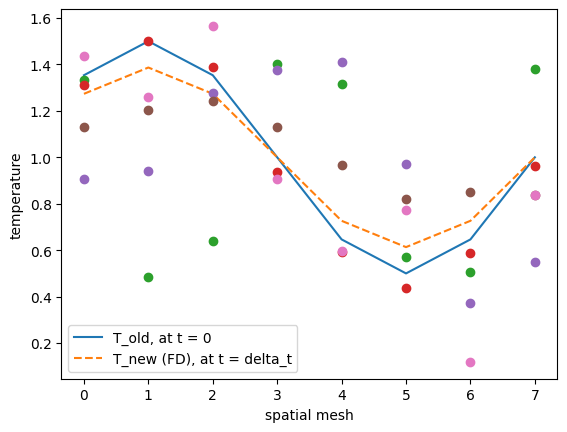

In [80]:
import matplotlib.pyplot as plt

pylab.rcParams["figure.figsize"] = (6.4, 4.8) # default (6.4, 4.8)
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')

all_values = []
for k in range(repetitions):
    results = all_results[k]
    # Estrai chiavi e valori
    keys = results.keys()
    values = results.values()

    # Ordina le chiavi in ordine binario crescente
    sorted_keys = sorted(results.keys())

    # Estrai i valori nell'ordine corretto
    sorted_values = [results[k] for k in sorted_keys]

    # Solution (quantum)
    y = np.real(list(sorted_values)) # probabilities
    x = np.sqrt(y) # amplitudes
    T_new_qiskitaer = x*scale

    if T_new_qiskitaer.shape == (N,):
        all_values.append(T_new_qiskitaer)

    plt.plot(T_new_qiskitaer, 'o', label='T_new_q (qiskit shots), at t = delta_t')

plt.show()

(5, 8)


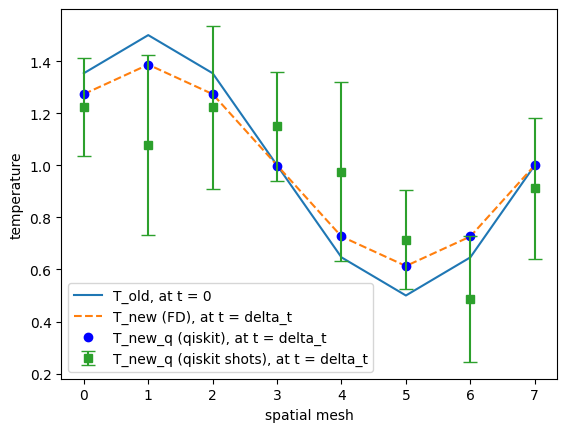

In [81]:
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.xlabel('spatial mesh')
plt.ylabel('temperature')

# Trasformiamo la lista di vettori in un array 2D: (30,8)
all_values = np.array(all_values)
print(all_values.shape)

# Ora calcoliamo:
mean_T = np.mean(all_values, axis=0)      # Media su ogni elemento
error_bar_T = np.std(all_values, axis=0)  # Errore = deviazione standard

# Plot con barre di errore
plt.errorbar(range(len(mean_T)), mean_T, yerr = error_bar_T, fmt='s', capsize=5, label='T_new_q (qiskit shots), at t = delta_t')
#plt.grid(True)
plt.legend()
plt.show()